# Logistic Regression for PCOS Diagnosis

This notebook implements a logistic regression model to predict PCOS diagnosis based on the provided dataset.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

%matplotlib inline

## 1. Load Data

In [15]:
df = pd.read_csv('../../data/processed/PCOS_data_cleaned.csv')
df.head()

,y,Age,Weight,Height,BMI,BloodGroup,PulseRate,RR,Hb,Cycle,...,Pimples,FastFood,RegExercise,BPSystolic,BPDiastolic,FollicleNoL,FollicleNoR,AvgFsizeL,AvgFsizeR,Endometrium
0,0,28,44.6,152.0,19.3,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.9,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,25.3,11,72,18,11.80,2,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.0,29.7,13,72,20,12.00,2,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.0,20.1,11,72,18,10.00,2,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 42 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   y               541 non-null    int64  
 1   Age             541 non-null    int64  
 2   Weight          541 non-null    float64
 3   Height          541 non-null    float64
 4   BMI             541 non-null    float64
 5   BloodGroup      541 non-null    int64  
 6   PulseRate       541 non-null    int64  
 7   RR              541 non-null    int64  
 8   Hb              541 non-null    float64
 9   Cycle           541 non-null    int64  
 10  CycleLength     541 non-null    int64  
 11  MarraigeStatus  540 non-null    float64
 12  Pregnant        541 non-null    int64  
 13  NoAbortions     541 non-null    int64  
 14  IbetaHCG        541 non-null    float64
 15  IIbetaHCG       541 non-null    float64
 16  FSH             541 non-null    float64
 17  LH              541 non-null    flo

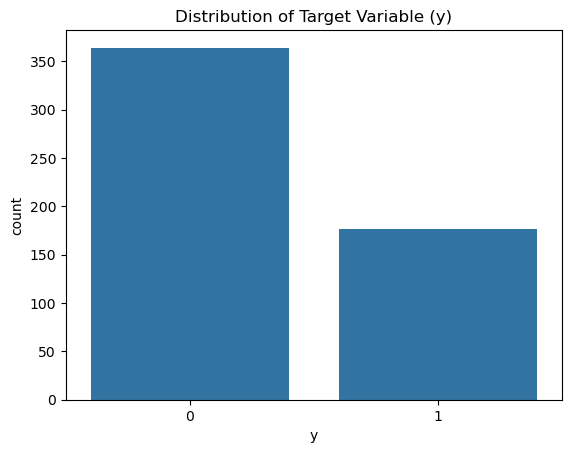

In [17]:
# Check target distribution
sns.countplot(x='y', data=df)
plt.title('Distribution of Target Variable (y)')
plt.show()

## 2. Preprocessing

In [18]:
# Check for missing values
print("Missing values before dropping:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Drop rows with missing values
df = df.dropna()
print("\nShape after dropping missing values:", df.shape)

Missing values before dropping:
MarraigeStatus    1
AMH               1
FastFood          1
dtype: int64

Shape after dropping missing values: (538, 42)


In [19]:
# Define features (X) and target (y)
X = df.drop('y', axis=1)
y = df['y']

In [20]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Logistic Regression Model

In [22]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 4. Evaluation

In [23]:
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

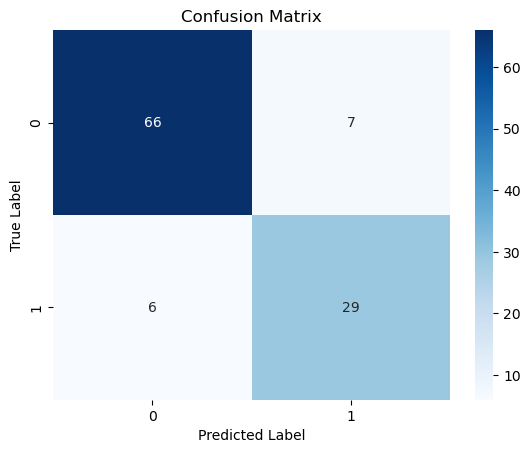

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [25]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91        73
           1       0.81      0.83      0.82        35

    accuracy                           0.88       108
   macro avg       0.86      0.87      0.86       108
weighted avg       0.88      0.88      0.88       108



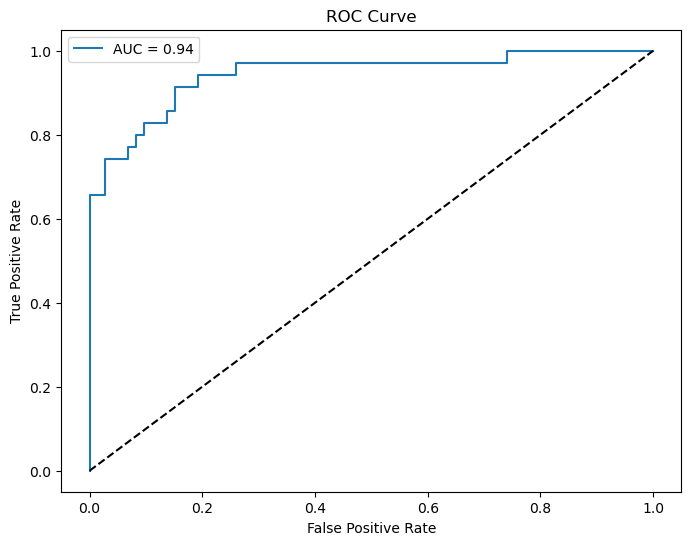

In [26]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()